In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, filtfilt
from skimage import data

In [4]:
data_mat = loadmat('./data/braindata.mat')

for k, v in data_mat.items():
    if not k.startswith('__'):
        print(f"{k}, {getattr(v, 'shape', None)}, {getattr(v, 'dtype', None)}")

braindata, (1, 1527), float32
srate, (1, 1), float64
timevec, (1, 1527), float64


c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


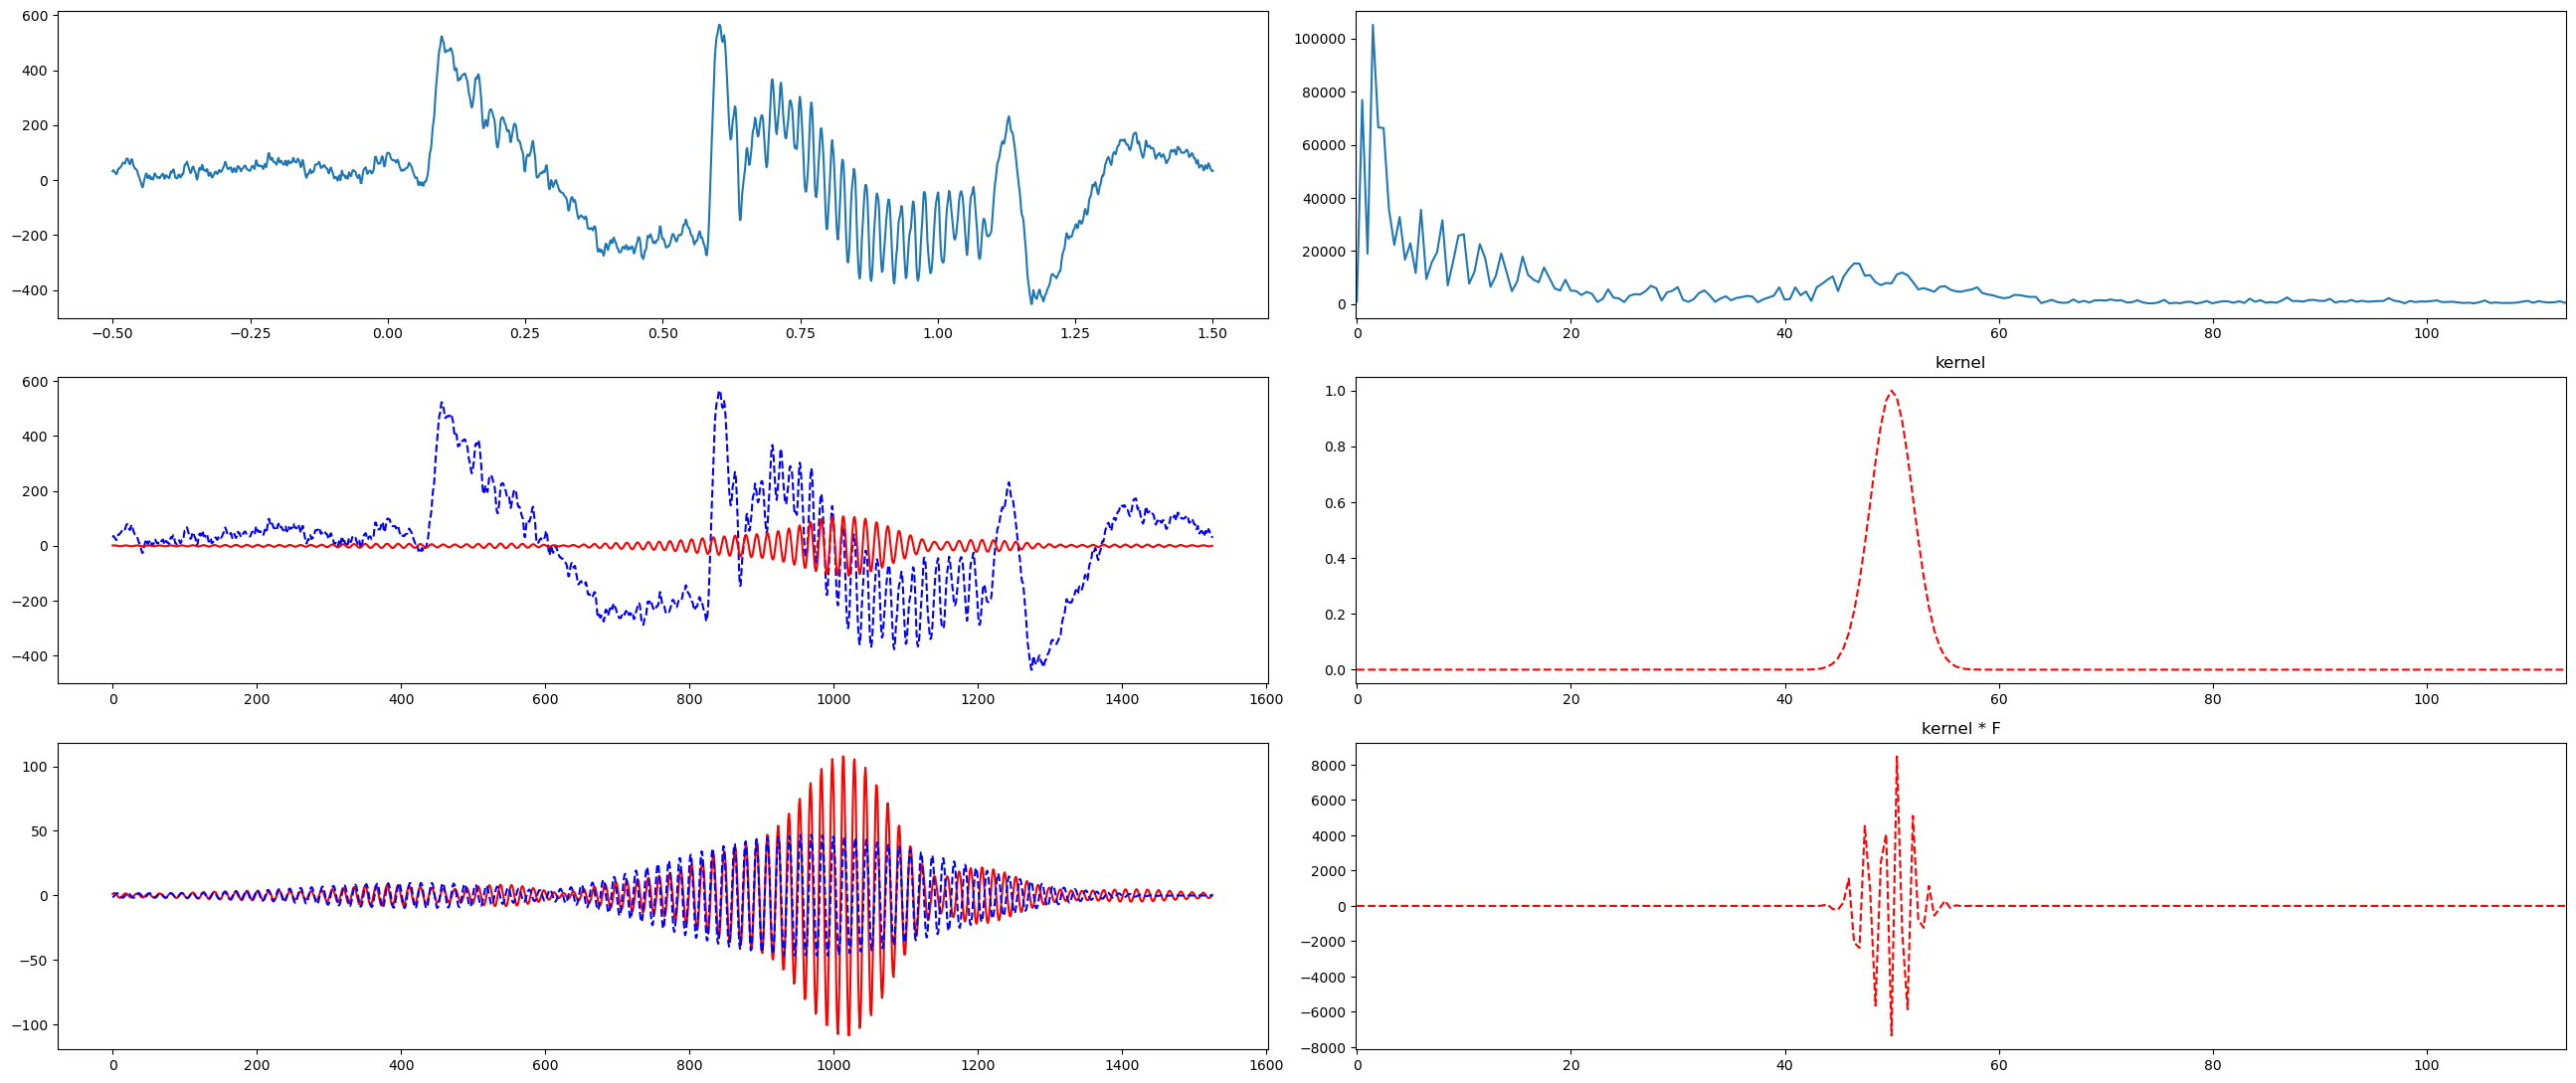

In [5]:
fs = data_mat['srate'].item()
t = data_mat['timevec'][0]
N = len(t)
braindata = data_mat['braindata'][0]
df = fs/N

std = 2
fc = 50

F = np.fft.rfft(braindata)

hz = np.fft.rfftfreq(N, 1/fs)
kernel = np.exp(-((hz - fc)**2)/(2 * std**2))

multip = kernel * F
signal_recon = np.fft.irfft(multip)


# Bandpath with library
low = fc - std/2
high = fc + std/2
b, a = butter(4, [low, high], btype='band', fs=fs) # type: ignore
filtered_signal = filtfilt(b, a, braindata)

plt.figure(figsize=(26, 11))
plt.subplot(321)
plt.plot(t, braindata)

plt.subplot(322)
plt.plot(hz, np.abs(F), label='F')
plt.xlim(-0.1, 113)

plt.subplot(324)
plt.plot(hz, kernel, 'r--', label='F')
plt.title('kernel')
plt.xlim(-0.1, 113)

plt.subplot(326)
plt.plot(hz, multip, 'r--', label='F')
plt.title('kernel * F')
plt.xlim(-0.1, 113)

plt.subplot(323)
plt.plot(braindata, 'b--', label='original')
plt.plot(signal_recon, 'r', label='filtered')

plt.subplot(325)
plt.plot(signal_recon, 'r', label='our way')
plt.plot(filtered_signal, 'b--', label='library')
# plt.xlim(1000, 1149)

plt.tight_layout()

Text(0.5, 1.0, 'Reconstructed')

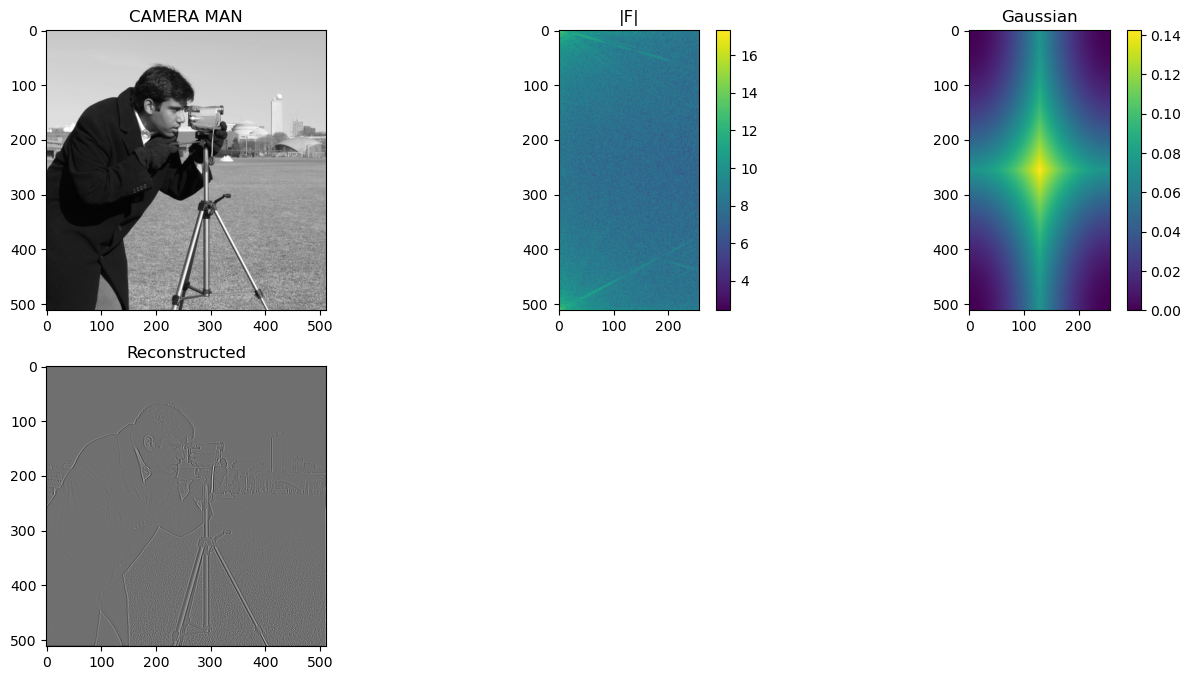

In [72]:
img = data.camera()

F = np.fft.rfft2(img)
# F = np.fft.fftshift(F) # center got DC componnt

std = 0.9

hz_y = np.fft.fftfreq(F.shape[0], 1)
hz_x = np.fft.fftfreq(F.shape[1], 1)
x_grid, y_grid = np.meshgrid(hz_x, hz_y)

gauss_2d = 1-np.exp(-(y_grid**2 + x_grid**2)/ (2 * std)**2)

filtered = F * gauss_2d
recon = np.fft.irfft2(filtered)

plt.figure(figsize=(15, 8))
plt.subplot(231)
plt.imshow(img, cmap='grey')
plt.title("CAMERA MAN")

plt.subplot(232)
plt.imshow(np.log1p(np.abs(F)))
plt.title("|F|")
plt.colorbar()

plt.subplot(233)
plt.imshow(gauss_2d)
plt.title("Gaussian")
plt.colorbar()

plt.subplot(234)
plt.imshow(recon, cmap='gray')
plt.title("Reconstructed")